In [ ]:
#04_scoring_system_evaluation.ipynb

# Scoring System Evaluation
#
# This notebook evaluates whether the wearable-style
# scoring system behaves intuitively relative to the
# underlying physiological signals and engineered features.
#
# Goals:
#
# - Visualize recovery, strain, and sleep scores
# - Compare scores against physiological signals
# - Validate feature-to-score relationships
# - Inspect day-to-day recovery dynamics
# - Ensure scoring logic remains interpretable

In [1]:
# ======================================================
# Imports
# ======================================================

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ------------------------------------------------------
# Allow notebook to access src/
# ------------------------------------------------------

sys.path.append(os.path.abspath(".."))

from src.data_generation import generate_wearable_data
from src.preprocessing import preprocess_data
from src.features import generate_features
from src.scoring import generate_scores

plt.rcParams["figure.figsize"] = (16, 5)
plt.rcParams["font.size"] = 11

In [3]:
# ======================================================
# Generate Full Pipeline Data
# ======================================================

raw_df = generate_wearable_data(days=7)

processed_df = preprocess_data(raw_df)

features_df = generate_features(processed_df)

scores_df = generate_scores(features_df)

print(scores_df.head())

         date  resting_hr  nightly_hrv  sleep_duration_hours  \
0  2024-01-01   35.869203    60.723296                   8.0   
1  2024-01-02   36.188748    60.644129                   8.0   
2  2024-01-03   35.904757    60.743127                   8.0   
3  2024-01-04   36.401894    60.910848                   8.0   
4  2024-01-05   36.356941    60.646901                   8.0   

   sleep_efficiency  rem_sleep_pct  deep_sleep_pct  light_sleep_pct  \
0             100.0           25.0           18.75            56.25   
1             100.0           25.0           18.75            56.25   
2             100.0           25.0           18.75            56.25   
3             100.0           25.0           18.75            56.25   
4             100.0           25.0           18.75            56.25   

   daily_activity_load  active_minutes  ...  zone2_minutes  zone3_minutes  \
0           363.833556              68  ...             32             24   
1           331.020413            

In [4]:
# ======================================================
# Daily Score Summary
# ======================================================

scores_df[[
    "date",
    "sleep_score",
    "recovery_score",
    "strain_score"
]]

,date,sleep_score,recovery_score,strain_score
0,2024-01-01,85.0,82.6,66.6
1,2024-01-02,85.0,82.6,69.5
2,2024-01-03,85.0,82.7,67.5
3,2024-01-04,85.0,82.8,74.4
4,2024-01-05,85.0,82.6,65.2
5,2024-01-06,85.0,82.9,NaN
6,2024-01-07,85.0,82.6,NaN


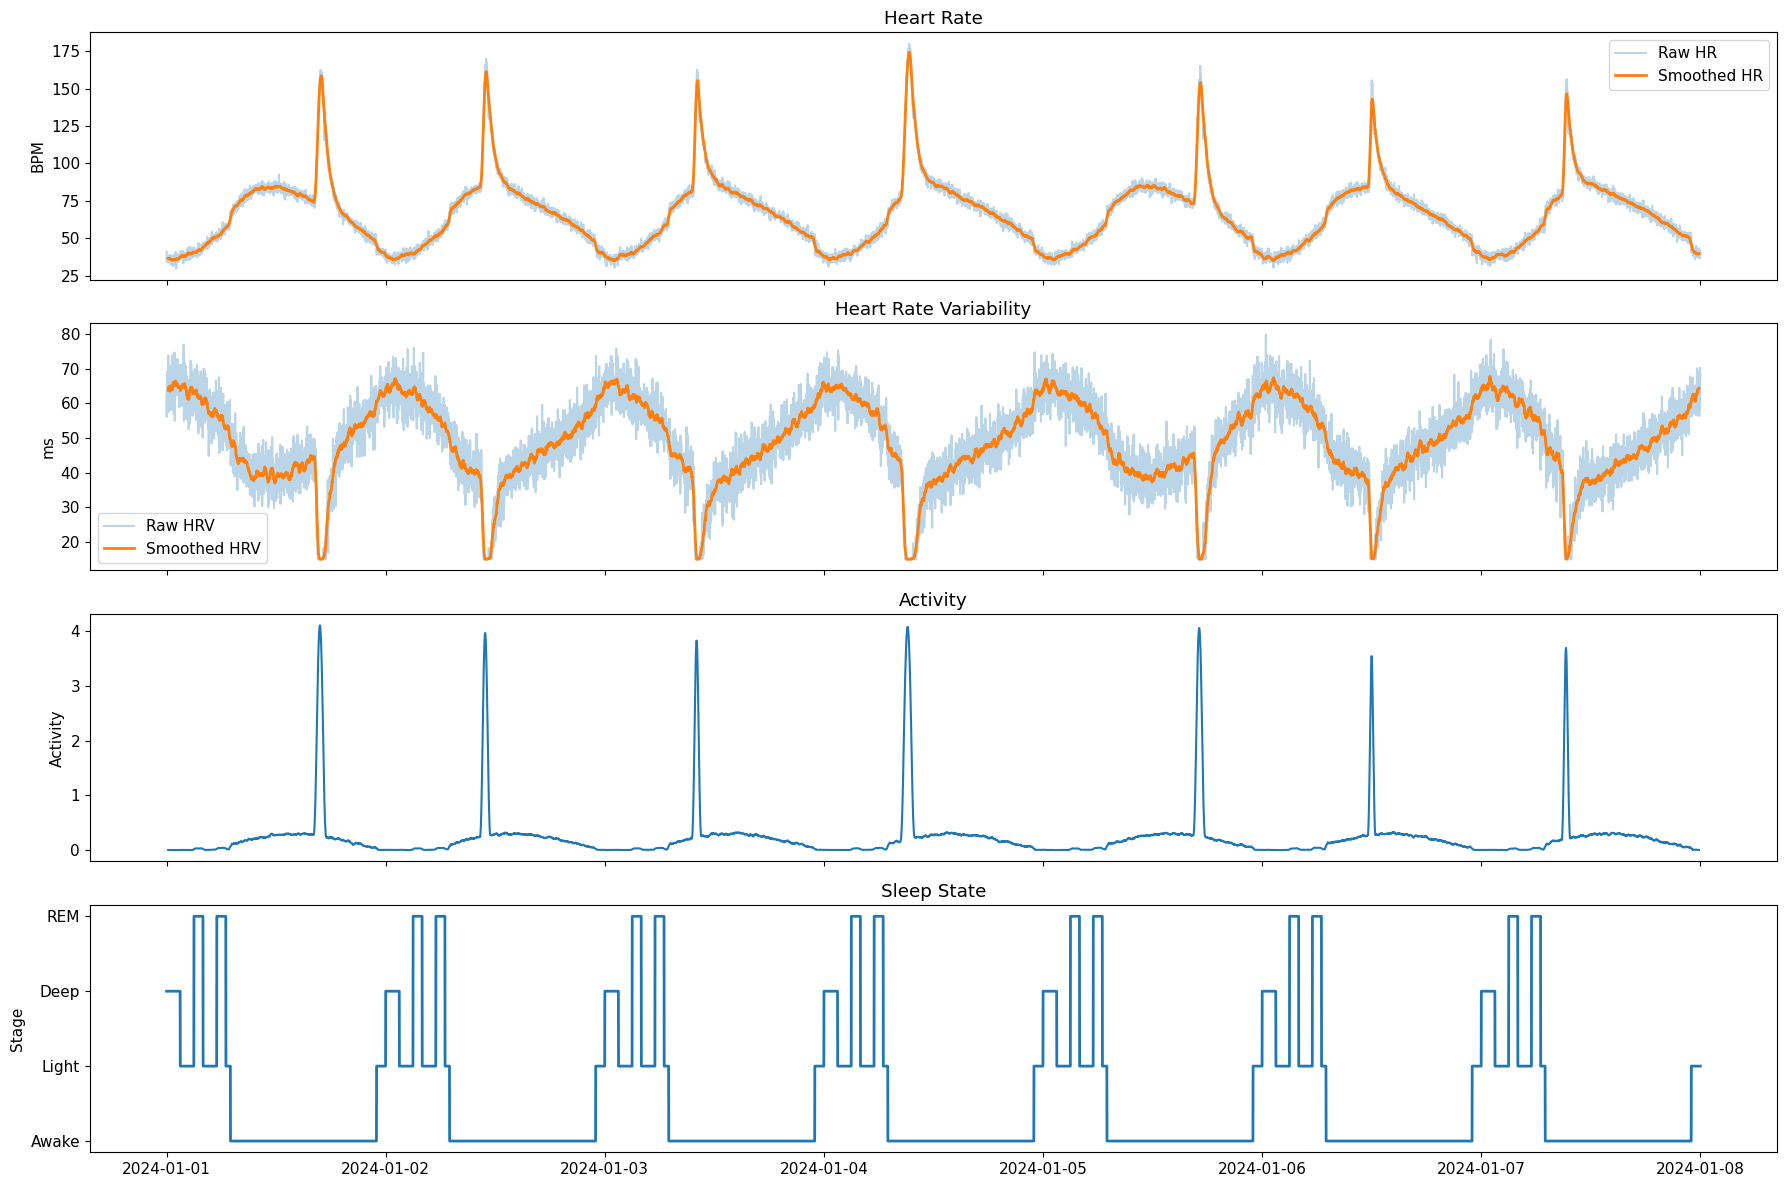

In [5]:
# ======================================================
# Multi-Day Physiological Signals
# ======================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(18, 12),
    sharex=True
)

# ------------------------------------------------------
# Heart Rate
# ------------------------------------------------------

axes[0].plot(
    processed_df["timestamp"],
    processed_df["hr"],
    alpha=0.3,
    label="Raw HR"
)

axes[0].plot(
    processed_df["timestamp"],
    processed_df["hr_smooth"],
    linewidth=2,
    label="Smoothed HR"
)

axes[0].set_title("Heart Rate")
axes[0].set_ylabel("BPM")
axes[0].legend()

# ------------------------------------------------------
# HRV
# ------------------------------------------------------

axes[1].plot(
    processed_df["timestamp"],
    processed_df["hrv"],
    alpha=0.3,
    label="Raw HRV"
)

axes[1].plot(
    processed_df["timestamp"],
    processed_df["hrv_smooth"],
    linewidth=2,
    label="Smoothed HRV"
)

axes[1].set_title("Heart Rate Variability")
axes[1].set_ylabel("ms")
axes[1].legend()

# ------------------------------------------------------
# Activity
# ------------------------------------------------------

axes[2].plot(
    processed_df["timestamp"],
    processed_df["activity_smooth"],
    linewidth=1.5
)

axes[2].set_title("Activity")
axes[2].set_ylabel("Activity")

# ------------------------------------------------------
# Sleep State
# ------------------------------------------------------

axes[3].plot(
    processed_df["timestamp"],
    processed_df["sleep_state"],
    linewidth=2
)

axes[3].set_title("Sleep State")
axes[3].set_ylabel("Stage")
axes[3].set_yticks([0, 1, 2, 3])
axes[3].set_yticklabels([
    "Awake",
    "Light",
    "Deep",
    "REM"
])

plt.tight_layout()
plt.show()

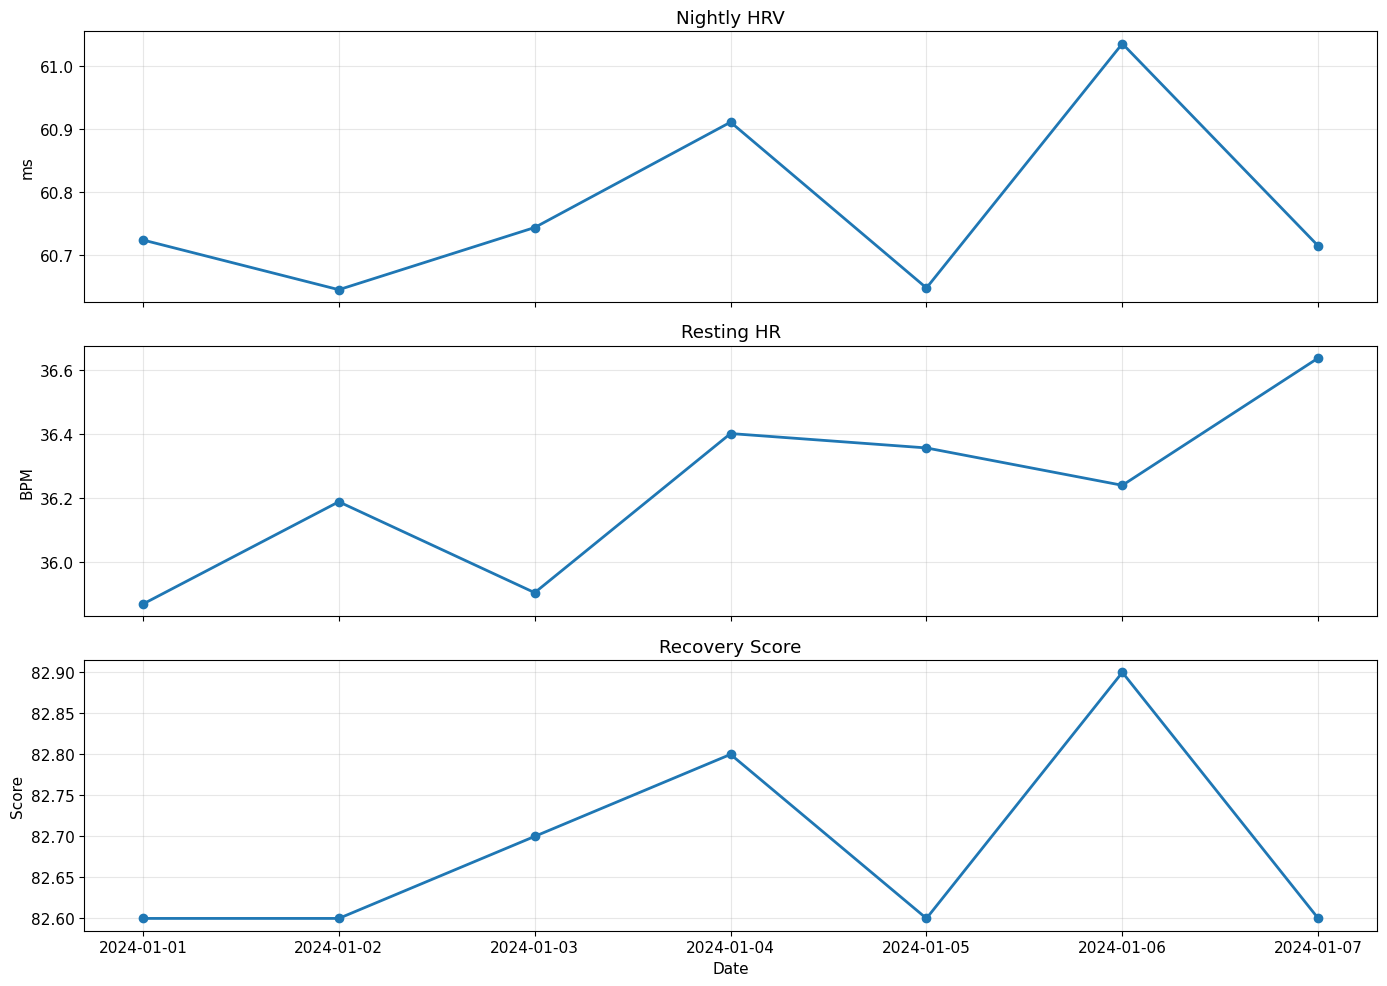

In [6]:
# ======================================================
# Recovery Score Components
# ======================================================
#
# Recovery should improve with:
#
# - higher HRV
# - lower resting HR
# - better sleep
# ======================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    sharex=True
)

# ------------------------------------------------------
# Nightly HRV
# ------------------------------------------------------

axes[0].plot(
    scores_df["date"],
    scores_df["nightly_hrv"],
    marker="o",
    linewidth=2
)

axes[0].set_title("Nightly HRV")
axes[0].set_ylabel("ms")

# ------------------------------------------------------
# Resting HR
# ------------------------------------------------------

axes[1].plot(
    scores_df["date"],
    scores_df["resting_hr"],
    marker="o",
    linewidth=2
)

axes[1].set_title("Resting HR")
axes[1].set_ylabel("BPM")

# ------------------------------------------------------
# Recovery Score
# ------------------------------------------------------

axes[2].plot(
    scores_df["date"],
    scores_df["recovery_score"],
    marker="o",
    linewidth=2
)

axes[2].set_title("Recovery Score")
axes[2].set_ylabel("Score")
axes[2].set_xlabel("Date")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

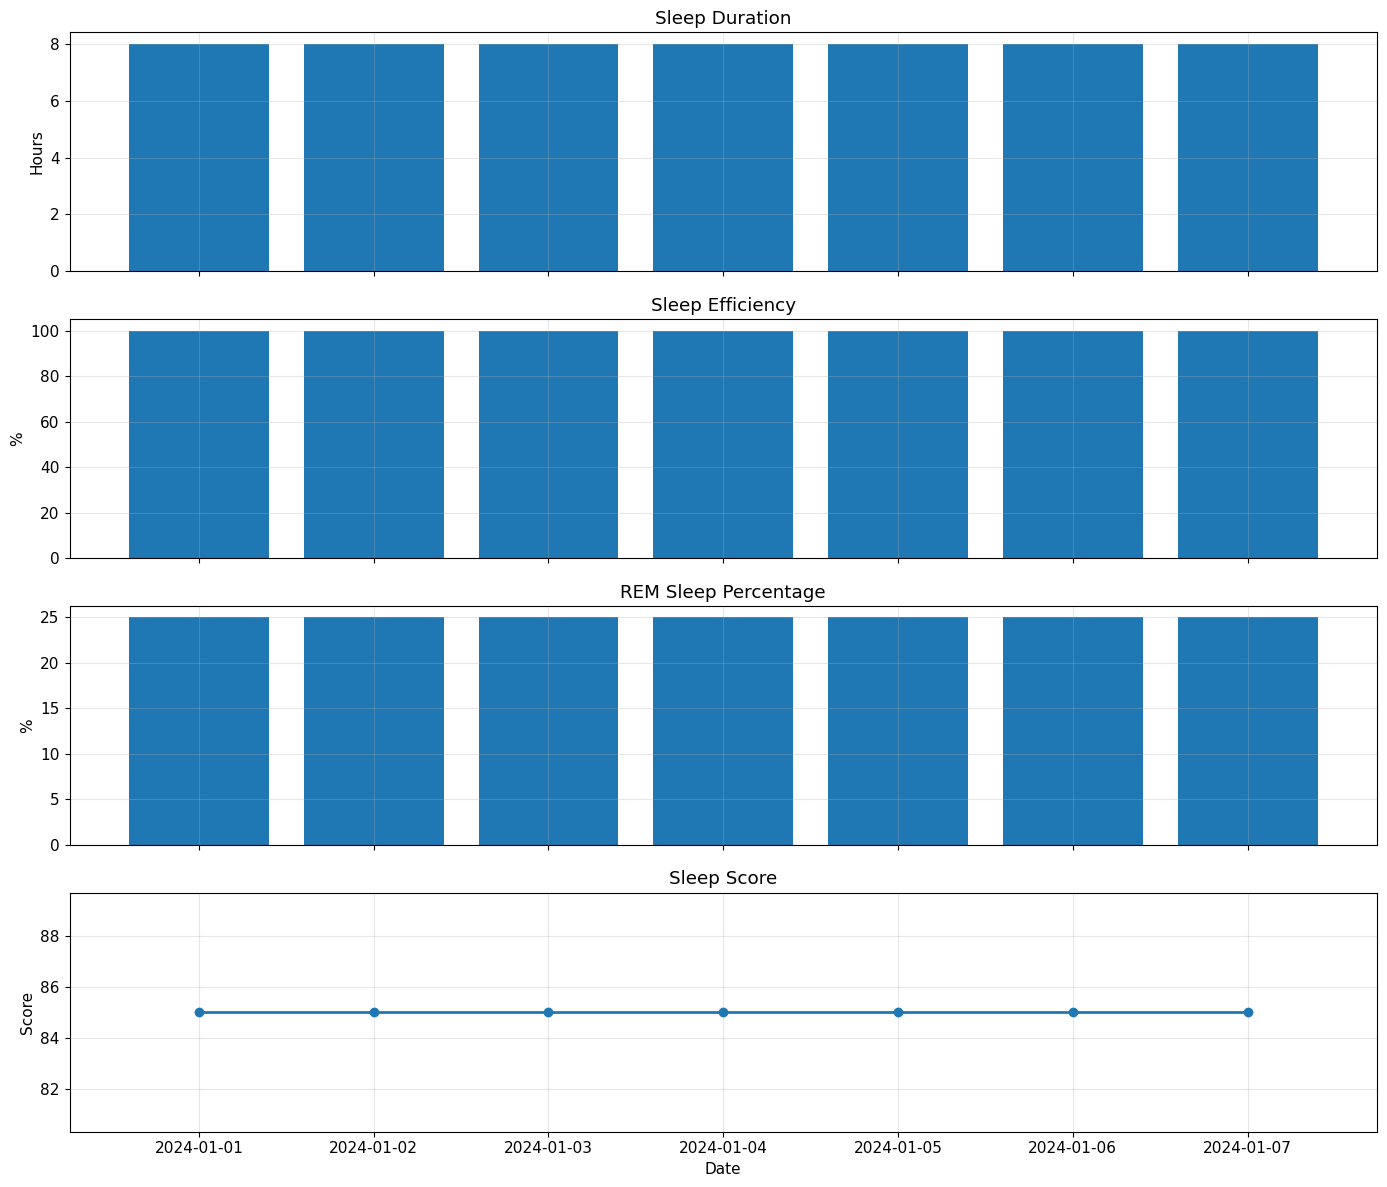

In [7]:
# ======================================================
# Sleep Score Components
# ======================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(14, 12),
    sharex=True
)

# ------------------------------------------------------
# Sleep Duration
# ------------------------------------------------------

axes[0].bar(
    scores_df["date"],
    scores_df["sleep_duration_hours"]
)

axes[0].set_title("Sleep Duration")
axes[0].set_ylabel("Hours")

# ------------------------------------------------------
# Sleep Efficiency
# ------------------------------------------------------

axes[1].bar(
    scores_df["date"],
    scores_df["sleep_efficiency"]
)

axes[1].set_title("Sleep Efficiency")
axes[1].set_ylabel("%")

# ------------------------------------------------------
# REM Percentage
# ------------------------------------------------------

axes[2].bar(
    scores_df["date"],
    scores_df["rem_sleep_pct"]
)

axes[2].set_title("REM Sleep Percentage")
axes[2].set_ylabel("%")

# ------------------------------------------------------
# Sleep Score
# ------------------------------------------------------

axes[3].plot(
    scores_df["date"],
    scores_df["sleep_score"],
    marker="o",
    linewidth=2
)

axes[3].set_title("Sleep Score")
axes[3].set_ylabel("Score")
axes[3].set_xlabel("Date")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

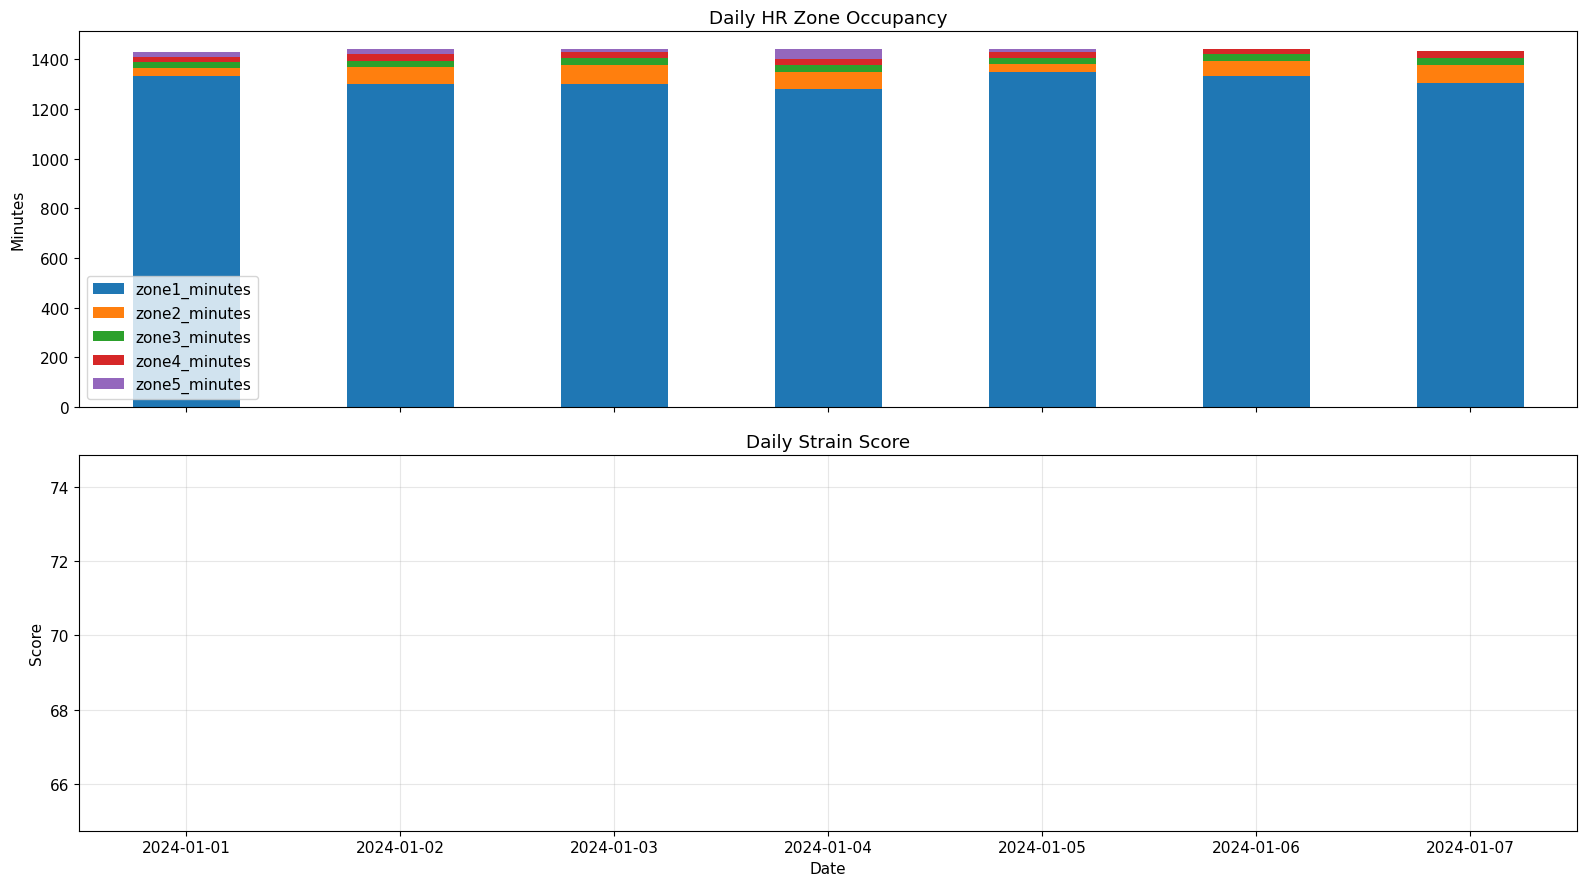

In [8]:
# ======================================================
# Strain Score Validation
# ======================================================
#
# Strain should increase with:
#
# - more elevated HR
# - more time in high HR zones
# - more exercise activity
# ======================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 9),
    sharex=True
)

# ------------------------------------------------------
# Daily HR Zone Minutes
# ------------------------------------------------------

zone_cols = [
    "zone1_minutes",
    "zone2_minutes",
    "zone3_minutes",
    "zone4_minutes",
    "zone5_minutes"
]

scores_df.plot(
    x="date",
    y=zone_cols,
    kind="bar",
    stacked=True,
    ax=axes[0]
)

axes[0].set_title("Daily HR Zone Occupancy")
axes[0].set_ylabel("Minutes")

# ------------------------------------------------------
# Strain Score
# ------------------------------------------------------

axes[1].plot(
    scores_df["date"],
    scores_df["strain_score"],
    marker="o",
    linewidth=2
)

axes[1].set_title("Daily Strain Score")
axes[1].set_ylabel("Score")
axes[1].set_xlabel("Date")

axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

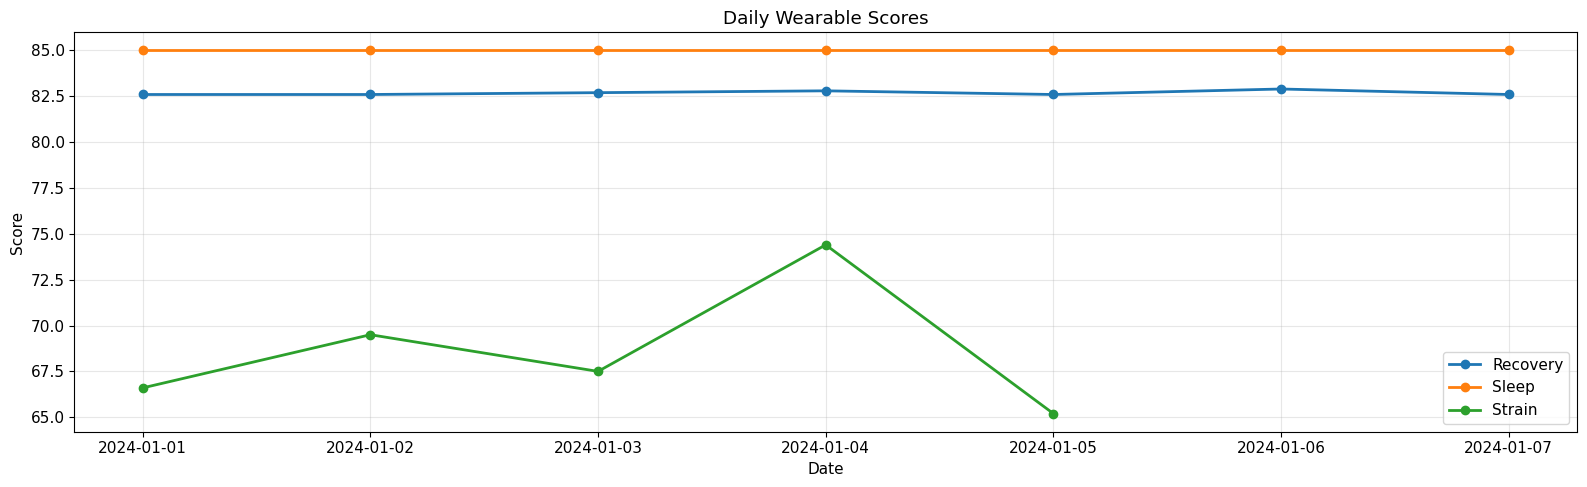

In [9]:
# ======================================================
# Score Comparison
# ======================================================

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    scores_df["date"],
    scores_df["recovery_score"],
    marker="o",
    linewidth=2,
    label="Recovery"
)

ax.plot(
    scores_df["date"],
    scores_df["sleep_score"],
    marker="o",
    linewidth=2,
    label="Sleep"
)

ax.plot(
    scores_df["date"],
    scores_df["strain_score"],
    marker="o",
    linewidth=2,
    label="Strain"
)

ax.set_title("Daily Wearable Scores")
ax.set_ylabel("Score")
ax.set_xlabel("Date")

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()


In [10]:
# ======================================================
# Score Interpretation Table
# ======================================================

summary_cols = [
    "date",
    "resting_hr",
    "nightly_hrv",
    "sleep_duration_hours",
    "sleep_efficiency",
    "daily_activity_load",
    "sleep_score",
    "recovery_score",
    "strain_score"
]

scores_df[summary_cols].round(2)

,date,resting_hr,nightly_hrv,sleep_duration_hours,sleep_efficiency,daily_activity_load,sleep_score,recovery_score,strain_score
0,2024-01-01,35.87,60.72,8.0,100.0,363.83,85.0,82.6,66.6
1,2024-01-02,36.19,60.64,8.0,100.0,331.02,85.0,82.6,69.5
2,2024-01-03,35.90,60.74,8.0,100.0,314.67,85.0,82.7,67.5
3,2024-01-04,36.40,60.91,8.0,100.0,391.49,85.0,82.8,74.4
4,2024-01-05,36.36,60.65,8.0,100.0,354.15,85.0,82.6,65.2
5,2024-01-06,36.24,61.04,8.0,100.0,282.13,85.0,82.9,NaN
6,2024-01-07,36.64,60.71,8.0,100.0,298.78,85.0,82.6,NaN
